# Занятие 16. Практика: разброс, аномалии и проверка гипотез — АВТОРСКОЕ РЕШЕНИЕ

> **Цель занятия:** провести настоящее расследование по данным. Заказчик задаёт вопрос,
> а мы ищем ответ: чистим аномалии, смотрим на распределения через **boxplot** и **violin**,
> проверяем догадки **t-тестом**, **критерием Манна–Уитни** и **χ²**.

**Что делаем сегодня:**
1. Разбираемся, что за вопрос у заказчика и в какой метрике лежат его деньги;
2. Ищем аномалии в данных — правилом **IQR** и по **Z-score** — и выясняем их **природу**;
3. Смотрим на распределения по группам и находим подозреваемого;
4. Проверяем догадки **тестами** и даём заказчику ответ, подкреплённый p-value.

Практика — **10 заданий, 30 баллов**. Пишите код в ячейках после `# Ваш код`, а там, где
просят, — короткий текст после `**Вывод:**`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')

---
## Вопрос заказчика

К вам пришёл руководитель сервиса доставки еды. Он говорит так:

> «Заказов у нас много, выручка растёт. Но **клиенты не возвращаются**: половина делает
> один заказ и пропадает. Каждого следующего клиента мы покупаем рекламой заново, и это
> съедает всю прибыль. Мы уже потратились на **промокоды** — не помогло.
>
> **Что мешает нам зарабатывать?**»

Заказчик не говорит, где искать. Он даёт данные и метрику, в которой лежат его деньги:
**`repeat_order`** — вернулся ли клиент за вторым заказом. Наша задача — найти, **что** сбивает
эту метрику, и доказать это числами, а не ощущениями.

### Данные

Таблица `data/orders.csv` — **2000 заказов** за месяц.

| Столбец | Что означает |
|---|---|
| `order_id` | номер заказа |
| `zone` | район города: `Центр`, `Северный`, `Приморский`, `Заречный` |
| `courier_type` | кто вёз: `пеший`, `вело`, `авто` |
| `promo` | был ли промокод: `да` / `нет` |
| `delivery_time` | **время доставки в минутах** |
| `order_sum` | сумма заказа, рублей |
| `rating` | оценка клиента, 1–5 |
| `repeat_order` | **вернулся ли клиент**: `1` — сделал повторный заказ, `0` — нет |

Главная рабочая гипотеза очевидна: **людей бесит долгое ожидание**. Но прежде чем её проверять,
данные придётся привести в порядок — иначе тесты соврут.

---
## Что понадобится из теории

Коротко напомним инструменты занятия 15 — все задания решаются ими.

**Поиск выбросов.** Правило **1.5 · IQR** опирается на квартили и устойчиво к самим выбросам:

```python
Q1 = df['x'].quantile(0.25)
Q3 = df['x'].quantile(0.75)
IQR = Q3 - Q1
low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
```

Правило **Z-score** смотрит, на сколько стандартных отклонений значение отстоит от среднего
(порог `|z| > 3`), но само страдает от выбросов — они раздувают `std`:

```python
z = (df['x'] - df['x'].mean()) / df['x'].std()
outliers = df[z.abs() > 3]
```

**Графики.** `sns.boxplot` показывает медиану, квартили, усы и точки-выбросы;
`sns.violinplot` добавляет к этому **форму** распределения и выдаёт несколько пиков.

**Тесты.** Выбор зависит от того, что сравниваем:

| Что сравниваем | Тест | Вызов |
|---|---|---|
| средние двух групп, данные ~нормальны | t-тест Стьюдента | `stats.ttest_ind(a, b)` |
| центры двух групп, есть скос и выбросы | Манна–Уитни | `stats.mannwhitneyu(a, b)` |
| доли (конверсия, повторные заказы) | χ² | `stats.chi2_contingency(table)` |

Решение всегда одно: **p-value < 0.05** — отвергаем H₀ (различие значимо);
**p-value ≥ 0.05** — улик недостаточно.

---
## Практика


### <font color='DarkOrange'>Задание 1 [2 балла]</font>

Загрузите таблицу `data/orders.csv` (разделитель `;`), выведите её размер и сводку
`.describe()` по столбцу `delivery_time`.

Посмотрите на `min`, `max`, `mean` и медиану (`50%`). Что в этих числах уже настораживает?

In [2]:
orders = pd.read_csv('data/orders.csv', sep=';')
print('Размер таблицы:', orders.shape)
orders['delivery_time'].describe().round(1)
# Ответ: (2000, 8); min 0.5, max 519.3, mean 43.0, медиана 35.5

Размер таблицы: (2000, 8)


count    2000.0
mean       43.0
std        45.5
min         0.5
25%        29.8
50%        35.5
75%        43.1
max       519.3
Name: delivery_time, dtype: float64

**Вывод:** доставка за **0.5 минуты** и за **519 минут** невозможна физически — в данных есть
аномалии. Среднее (**43.0**) заметно выше медианы (**35.5**), значит крайние значения тянут его
вверх.

### <font color='DarkOrange'>Задание 2 [3 балла]</font>

Найдите выбросы в `delivery_time` по правилу **1.5 · IQR**: посчитайте `Q1`, `Q3`, `IQR`,
нижнюю и верхнюю границы нормы и выведите, **сколько** заказов вышло за эти границы.

In [3]:
Q1 = orders['delivery_time'].quantile(0.25)
Q3 = orders['delivery_time'].quantile(0.75)
IQR = Q3 - Q1

low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
print('Q1 =', Q1, '| Q3 =', Q3, '| IQR =', round(IQR, 1))
print('границы нормы: от', round(low, 1), 'до', round(high, 1))

outliers_iqr = orders[(orders['delivery_time'] < low) | (orders['delivery_time'] > high)]
print('выбросов по IQR:', len(outliers_iqr))
# Ответ: Q1=29.8, Q3=43.1, IQR=13.3, границы 9.8..63.1, выбросов 211

Q1 = 29.8 | Q3 = 43.125 | IQR = 13.3
границы нормы: от 9.8 до 63.1
выбросов по IQR: 211


### <font color='DarkOrange'>Задание 3 [3 балла]</font>

Найдите выбросы по **Z-score** (порог `|z| > 3`). Выведите их количество и **минимальное**
время доставки среди них. Сравните результат с заданием 2.

Почему правила разошлись так сильно? Подсказка: посмотрите на `std` и медиану.

In [4]:
z = (orders['delivery_time'] - orders['delivery_time'].mean()) / orders['delivery_time'].std()
outliers_z = orders[z.abs() > 3]

print('выбросов по Z-score:', len(outliers_z))
print('минимальное время среди них:', outliers_z['delivery_time'].min())
print('std =', round(orders['delivery_time'].std(), 1), '| медиана =', orders['delivery_time'].median())
# Ответ: 32 выброса, минимум 280.6 мин; std=45.5 при медиане 35.5

выбросов по Z-score: 32
минимальное время среди них: 280.6
std = 45.5 | медиана = 35.5


**Вывод:** Z-score нашёл всего **32** заказа против **211** по IQR, и все они — дольше
**280 минут**. Стандартное отклонение (**45.5**) само раздуто этими «зависшими» заказами и
почти равно медиане (**35.5**), поэтому порог `среднее + 3·std` уехал далеко вправо: выбросы
портят ту самую меру, которой их ищут.

### <font color='DarkOrange'>Задание 4 [3 балла]</font>

Разберитесь в **природе** аномалий — удалять вслепую нельзя. Отберите заказы с
`delivery_time < 5` и заказы с `delivery_time > 180` и посмотрите, **какие курьеры**
их выполняли (`value_counts()` по `courier_type` среди медленных).

Кто виноват в «зависших» заказах?

In [5]:
fast_bug = orders[orders['delivery_time'] < 5]
slow_bug = orders[orders['delivery_time'] > 180]

print('доставок быстрее 5 минут:', len(fast_bug))
print('доставок дольше 180 минут:', len(slow_bug))
print()
print('кто вёз «зависшие» заказы:')
print(slow_bug['courier_type'].value_counts())
# Ответ: 45 заказов < 5 мин; 32 заказа > 180 мин, из них 28 — вело

доставок быстрее 5 минут: 45
доставок дольше 180 минут: 32

кто вёз «зависшие» заказы:
courier_type
вело    28
авто     4
Name: count, dtype: int64


**Вывод:** это не клиенты и не пробки, а **сбои приложения**. 45 заказов «доставлены» за
минуту — курьер нажал кнопку сразу; 32 заказа висят по 5–8 часов, и **28 из 32** приходятся на
**велокурьеров** — очевидный баг в их версии приложения: заказ не закрывается автоматически.
Эти строки не описывают реальную доставку, поэтому их надо убрать.

### <font color='DarkOrange'>Задание 5 [2 балла]</font>

Теперь примените то же правило **1.5 · IQR** к столбцу `order_sum`. Выведите верхнюю границу,
число заказов за ней и **сколько** из них дороже 8000 рублей (это корпоративные заказы на офис).

Надо ли удалять эти аномалии? Ответьте в выводе.

In [6]:
Q1s = orders['order_sum'].quantile(0.25)
Q3s = orders['order_sum'].quantile(0.75)
high_s = Q3s + 1.5 * (Q3s - Q1s)

big = orders[orders['order_sum'] > high_s]
print('верхняя граница по IQR:', round(high_s))
print('заказов за границей:', len(big))
print('из них дороже 8000 руб (корпоративные):', (orders['order_sum'] >= 8000).sum())
# Ответ: граница 1682 руб, за ней 97 заказов, из них 55 корпоративных

верхняя граница по IQR: 1682
заказов за границей: 97
из них дороже 8000 руб (корпоративные): 55


**Вывод:** удалять **нельзя**. Правило IQR пометило **97** заказов, но это не ошибки: 55 из
них — корпоративные заказы на офис (8000–21000 руб), а остальные — просто крупные семейные
заказы. Это **настоящие редкие значения**, причём самые прибыльные клиенты. Здесь формальное
правило ошибается: сумма заказа скошена вправо, и IQR штампует «выбросы» из честных данных.

### <font color='DarkOrange'>Задание 6 [3 балла]</font>

Соберите чистую таблицу `clean`: оставьте только заказы с временем доставки **от 5 до 180**
минут включительно (`order_sum` не трогаем — там аномалий нет).

Выведите, сколько строк осталось, и сравните **среднее** время доставки до и после чистки.

In [7]:
clean = orders[(orders['delivery_time'] >= 5) & (orders['delivery_time'] <= 180)].copy()

print('было строк:', len(orders), '→ стало:', len(clean))
print('среднее время до чистки: ', round(orders['delivery_time'].mean(), 1))
print('среднее время после:     ', round(clean['delivery_time'].mean(), 1))
# Ответ: 2000 → 1923; среднее 43.0 → 38.4

было строк: 2000 → стало: 1923
среднее время до чистки:  43.0
среднее время после:      38.4


**Вывод:** удалили **77** строк (менее 4% данных), а среднее время доставки упало с **43.0**
до **38.4** минуты. Отчёт заказчику по сырым данным завышал время почти на пять минут — при
том, что сами сбои никакого отношения к реальной доставке не имеют.

### <font color='DarkOrange'>Задание 7 [3 балла]</font>

Найдите подозреваемого. Постройте по таблице `clean`:

- **boxplot** времени доставки по районам (`zone`);
- **violinplot** времени доставки по районам.

Какой район выбивается? Что violin показывает внутри него такого, чего не видно на boxplot?

zone
Заречный      57.6
Приморский    33.4
Северный      35.6
Центр         31.9
Name: delivery_time, dtype: float64


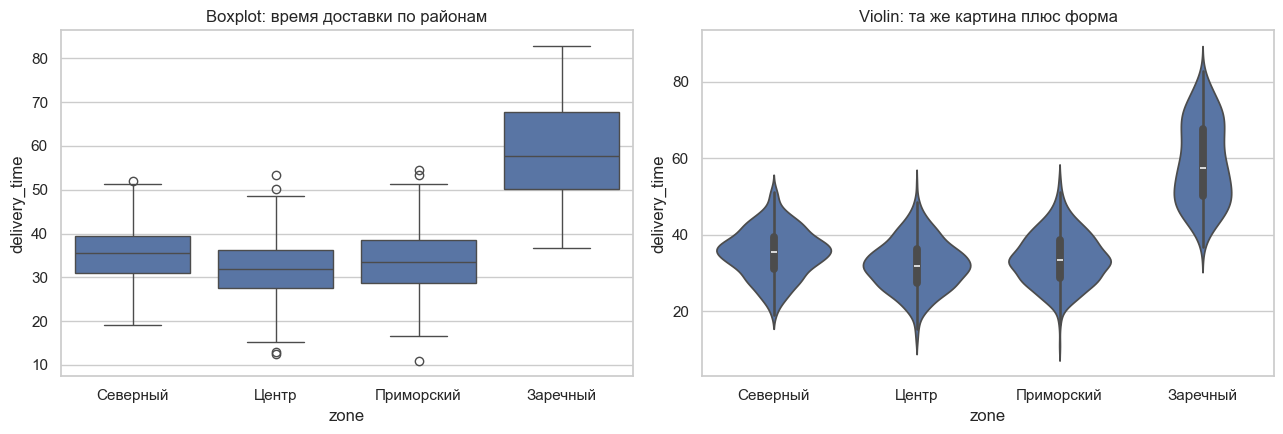

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=clean, x='zone', y='delivery_time', ax=axes[0])
axes[0].set_title('Boxplot: время доставки по районам')

sns.violinplot(data=clean, x='zone', y='delivery_time', ax=axes[1])
axes[1].set_title('Violin: та же картина плюс форма')

plt.tight_layout()

print(clean.groupby('zone')['delivery_time'].median().round(1))
# Ответ: медианы — Заречный 57.6, Северный 35.6, Приморский 33.4, Центр 31.9

**Вывод:** резко выбивается **Заречный**: медиана **57.6** минуты против 32–36 у остальных
районов. На violin видно то, чего не даёт boxplot: «скрипка» Заречного имеет **два пика** —
часть адресов обслуживается быстро, а часть (вероятно, за мостом) уходит далеко вправо.
Это не один медленный район, а **две разные аудитории** внутри него.

### <font color='DarkOrange'>Задание 8 [4 балла]</font>

Проверим вторую догадку: **пешие курьеры медленнее велокурьеров**.

1. Сравните `t-тестом` время доставки пеших и вело **на исходной** таблице `orders`
   (со сбоями). Выведите средние и p-value.
2. Повторите **на чистой** таблице `clean`.
3. Запустите на **исходных** данных `критерий Манна–Уитни` и выведите медианы.

Сравните три результата. Почему t-тест на сырых данных дал такой ответ, а Манна–Уитни — нет?

In [9]:
peshiy_raw = orders[orders['courier_type'] == 'пеший']['delivery_time']
velo_raw   = orders[orders['courier_type'] == 'вело']['delivery_time']

print('СЫРЫЕ ДАННЫЕ (t-тест)')
print('  пеший:', round(peshiy_raw.mean(), 1), '| вело:', round(velo_raw.mean(), 1))
print('  p-value =', round(stats.ttest_ind(peshiy_raw, velo_raw).pvalue, 3))

peshiy = clean[clean['courier_type'] == 'пеший']['delivery_time']
velo   = clean[clean['courier_type'] == 'вело']['delivery_time']

print('\nЧИСТЫЕ ДАННЫЕ (t-тест)')
print('  пеший:', round(peshiy.mean(), 1), '| вело:', round(velo.mean(), 1))
print('  p-value =', stats.ttest_ind(peshiy, velo).pvalue)

print('\nСЫРЫЕ ДАННЫЕ (Манна–Уитни)')
print('  медианы:', peshiy_raw.median(), '|', velo_raw.median())
print('  p-value =', stats.mannwhitneyu(peshiy_raw, velo_raw).pvalue)
# Ответ: сырые t-тест — 46.2 / 49.0, p = 0.337 (различий «нет», вело даже «медленнее»)
#        чистые t-тест — 46.8 / 37.4, p ≈ 4.9e-38 (пешие медленнее на 9 минут)
#        сырые Манна–Уитни — медианы 42.5 / 35.3, p ≈ 1.2e-31 (различие видит сразу)

СЫРЫЕ ДАННЫЕ (t-тест)
  пеший: 46.2 | вело: 49.0
  p-value = 0.337

ЧИСТЫЕ ДАННЫЕ (t-тест)
  пеший: 46.8 | вело: 37.4
  p-value = 4.861960832785563e-38

СЫРЫЕ ДАННЫЕ (Манна–Уитни)
  медианы: 42.55 | 35.3
  p-value = 1.2417769241300788e-31


**Вывод:** на сырых данных t-тест **соврал**: он показал, что вело даже «медленнее» пеших
(49.0 против 46.2) и что разница незначима (p = 0.337). Причина — 28 зависших заказов
велокурьеров: они раздули **среднее** и разброс именно у вело. После чистки картина
**переворачивается**: пешие 46.8 против вело 37.4, p ≈ 5e-38.

Манна–Уитни дал верный ответ **даже на грязных данных** (медианы 42.5 против 35.3, p ≈ 1e-31):
он работает с **рангами**, и заказ на 500 минут для него просто «последний в очереди», а не
гигантское число.

### <font color='DarkOrange'>Задание 9 [4 балла]</font>

Пора ответить на главный вопрос: **бьёт ли долгая доставка по повторным заказам**.

На таблице `clean` создайте признак «долгая доставка» (`delivery_time > 45`), постройте
таблицу сопряжённости с `repeat_order` через `pd.crosstab`, посчитайте **долю повторных
заказов** в каждой группе и проверьте гипотезу **критерием χ²**.

Сформулируйте H₀ и вывод по p-value.

In [10]:
clean['slow'] = clean['delivery_time'] > 45

table = pd.crosstab(clean['slow'], clean['repeat_order'])
print(table)

print('\nдоля повторных заказов:')
print((table[1] / table.sum(axis=1)).round(3))

chi2, p_value, dof, expected = stats.chi2_contingency(table)
print('\nchi2 =', round(chi2, 1), '| p-value =', p_value)
# Ответ: доля повторных — 0.448 при быстрой доставке и 0.221 при долгой;
#        chi2 = 66.9, p ≈ 2.9e-16 → H0 отвергаем

repeat_order    0    1
slow                  
False         842  682
True          311   88

доля повторных заказов:
slow
False    0.448
True     0.221
dtype: float64

chi2 = 66.9 | p-value = 2.8566854591861667e-16


**Вывод:** H₀ — «скорость доставки не влияет на повторный заказ». Доля вернувшихся клиентов
падает с **44.8%** при быстрой доставке до **22.1%** при доставке дольше 45 минут — **вдвое**.
p-value ≈ 3e-16, много меньше 0.05, поэтому **H₀ отвергаем**: долгое ожидание действительно
убивает повторные заказы. Вот где утекают деньги заказчика.

### <font color='DarkOrange'>Задание 10 [3 балла]</font>

Заказчик уверен, что дело в **промокодах** — на них уже потратились. Проверьте эту версию:
постройте на `clean` таблицу сопряжённости `promo` и `repeat_order`, посчитайте доли и
примените **χ²**.

В выводе дайте **финальный ответ заказчику**: что мешает зарабатывать и что делать.

In [11]:
table_promo = pd.crosstab(clean['promo'], clean['repeat_order'])
print(table_promo)

print('\nдоля повторных заказов:')
print((table_promo[1] / table_promo.sum(axis=1)).round(3))

chi2, p_value, dof, expected = stats.chi2_contingency(table_promo)
print('\nchi2 =', round(chi2, 2), '| p-value =', round(p_value, 3))

print('\nдоля повторных заказов по районам:')
print(clean.groupby('zone')['repeat_order'].mean().round(3))
# Ответ: доли 0.398 (промо) и 0.402 (без промо), chi2 = 0.01, p = 0.908 → H0 не отвергаем
#        повторные по районам: Заречный 0.251 против 0.43-0.44 у остальных

repeat_order    0    1
promo                 
да            407  269
нет           746  501

доля повторных заказов:
promo
да     0.398
нет    0.402
dtype: float64

chi2 = 0.01 | p-value = 0.908

доля повторных заказов по районам:
zone
Заречный      0.251
Приморский    0.440
Северный      0.428
Центр         0.438
Name: repeat_order, dtype: float64


**Вывод:** промокод **не влияет** на возврат клиента: 39.8% против 40.2%, p-value = **0.908**,
H₀ не отвергаем — улик нет. Деньги на промокоды потрачены впустую.

**Ответ заказчику.** Клиенты не возвращаются из-за **долгой доставки**: при ожидании дольше
45 минут доля повторных заказов падает вдвое (44.8% → 22.1%, p ≈ 3e-16). Источник задержек —
**Заречный** район (медиана 57.6 минуты против 32–36 у остальных; повторных заказов там всего
25% против 43–44%) и **пешие курьеры** (46.8 минуты против 37.4 у вело, p ≈ 5e-38). Что делать:
перевести Заречный на авто- и велодоставку, а не тратить бюджет на промокоды. Отдельно —
починить приложение велокурьеров: 28 заказов «висят» незакрытыми и портят всю отчётность.